In [3]:
from gsnn_mds.proc.proc import process_expression_data, process_mds_expression_data, load_and_process_drug_data 
from argparse import Namespace 
import os
import pandas as pd 
from gsnn_mds.data.AMLDataset import AMLDataset  
import numpy as np
import torch
from torch.utils.data import DataLoader

from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP 
from hnet.train.hnet import EnergyDistanceLoss

from sklearn.metrics import r2_score
from matplotlib import pyplot as plt 

from dvgs.DVGS import DVGS

# auto reimport 
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# MDS DOMAIN ADAPTATION WITH DATA VALUATION

Premise: Train a hypernet on AML samples and finetune the model on AML (PriorMDS=True). 

## Define args 

In [140]:
args = Namespace() 

args.data_root = '/home/teddy/local/data/evansmds/'
args.expr_norm = "rank_inv_normal"
args.expr_clip_quantiles = (0.02, 0.98) # Not used for rank_inv_normal
args.expr_normalizer_save_path = None
args.expr_n_top_genes = 1000
args.expr_var_threshold = 0.1 # Not used if expr_n_top_genes is not None
args.resp_norm = "zscore"

args.hidden_channels = 512
args.n_layers = 4
args.nonlin = 'elu'
args.dropout = 0.05
args.norm = 'layer'

args.batch_size = 1024
args.train_epochs = 50
args.lr = 5e-4
args.weight_decay = 1e-6
args.device = 'cuda'




# Preprocess Data 

In [5]:
mds_expr_path = os.path.join(args.data_root, '20241219_WTS_Data_Proj805.csv') 
expression_data_path = os.path.join(args.data_root, 'aml_full_manuscript.csv')

# only use genes that are in the MDS expression data 
mds_genes = pd.read_csv(mds_expr_path, sep='\t').gene_id.unique().tolist()
print('# MDS gene candidates: ', len(mds_genes))


aml_expr, normalizer = process_expression_data(
    expression_data_path, mds_genes, args.expr_norm,
    quantile_clip=tuple(args.expr_clip_quantiles),
    normalizer_save_path=args.expr_normalizer_save_path,
    n_top_genes=args.expr_n_top_genes,
    var_threshold=args.expr_var_threshold
)

# MDS gene candidates:  26364
Loading gene expression data...
Selecting variable genes...
Selected top 1000 most variable genes
Applied rank_inv_normal normalization
Processed expression data: 560 samples x 1000 genes


In [6]:
# Process MDS expression data using the same normalizer
mds_expr = process_mds_expression_data(
    mds_expr_path, normalizer
)

expr = pd.concat([aml_expr, mds_expr])

Loading MDS expression data...
Applied rank_inv_normal normalization to MDS data
Processed MDS expression data: 683 samples x 1000 genes


In [7]:
# Load and process drug response data
drug_data_path = os.path.join(args.data_root, 'beataml_probit_curve_fits_v4_distr.txt')
clinical_data_path = os.path.join(args.data_root, 'beataml_clinical_for_inputs.csv')

drug = load_and_process_drug_data(drug_data_path, clinical_data_path, args.resp_norm)

# Get drug candidates for filtering
drug_candidates = (drug.inhibitor_1.str.lower().unique().tolist() + 
                    drug.inhibitor_2.str.lower().unique().tolist())
drug_candidates = [x for x in drug_candidates if pd.notna(x)]

print('# Drug candidates: ', len(drug_candidates)) 

Loading drug response data...
Loaded 68525 drug response measurements
# Drug candidates:  349


In [8]:
drug_df = pd.DataFrame({f'DRUG__{drug_name}':np.zeros(len(expr)) for drug_name in drug_candidates})
drug_df.index = expr.index 

input_df = pd.concat([expr.astype(np.float32), drug_df.astype(np.float32)], axis=1) 
input_names = input_df.columns.tolist()  

print('# Input features: ', len(input_names))  

# Input features:  1312


In [9]:
drug_ids = drug.id.unique().tolist() 
input_ids = input_df.index.unique().tolist()  

# any drug ids not in input_ids? 
no_input_drug_ids = [x for x in drug_ids if x not in input_ids]
print('# Drug IDs not in input: ', len(no_input_drug_ids))

# remove drug ids that don't have input features 
drug = drug.loc[drug.id.isin(input_ids)]


# Drug IDs not in input:  4


In [10]:
id2x = {patient_id: torch.tensor(input_df.loc[patient_id].values, dtype=torch.float)
         for patient_id in input_df.index.tolist()}

In [11]:
# Need to create train/finetune/test splits 
# 1. Finetune on AML samples (PriorMDS=False)
# 2. Finetune on MDS samples (PriorMDS=True) ; fraction of samples 
# 3. Test on MDS samples (PriorMDS=True) ; fraction of samples 

aml_clin = pd.read_csv(os.path.join(args.data_root, 'beataml_clinical_for_inputs.csv'))

prior_mds_ids = aml_clin[lambda x: (x.priorMDS == 'y') &  
                                (x['FLT3-ITD'] == 'negative')
                        ].gdc_id.tolist()

prior_mds_ids = [x for x in prior_mds_ids if x in drug_ids] 
prior_mds_ids = [x for x in prior_mds_ids if x in input_ids] 

# 2:1 split between test/finetune  
finetune_ids = np.random.choice(prior_mds_ids, size=int(len(prior_mds_ids)*0.5), replace=False)
test_ids = [x for x in prior_mds_ids if x not in finetune_ids]
train_ids = [x for x in drug.id.unique().tolist() if x not in prior_mds_ids]

train_dataset = AMLDataset(id2x, drug[lambda x: x.id.isin(train_ids)].reset_index(drop=True), input_names)
finetune_dataset = AMLDataset(id2x, drug[lambda x: x.id.isin(finetune_ids)].reset_index(drop=True), input_names)
test_dataset = AMLDataset(id2x, drug[lambda x: x.id.isin(test_ids)].reset_index(drop=True), input_names)

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)
finetune_loader = DataLoader(finetune_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=4)

print(f'# train samples: {len(train_dataset)} [# patients: {len(train_ids)}]')
print(f'# finetune samples: {len(finetune_dataset)} [# patients: {len(finetune_ids)}]')
print(f'# test samples: {len(test_dataset)} [# patients: {len(test_ids)}]')


# train samples: 62458 [# patients: 396]
# finetune samples: 2632 [# patients: 17]
# test samples: 3012 [# patients: 18]


# Initialize Model 

In [ ]:

# requirements of  DVGS
class MLP2(MLP):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def reset_parameters(self): 

        def weight_reset(m):
            if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Linear) or isinstance(m, torch.nn.ConvTranspose2d):
                m.reset_parameters()

        self.apply(weight_reset)

In [93]:
model = MLP2(in_channels = len(input_names), 
          out_channels = 1, 
          hidden_channels = args.hidden_channels, 
          layers = args.n_layers, 
          nonlin = args.nonlin,
          dropout = args.dropout, 
          norm = args.norm).to(args.device)



# Get Datasets 

In [20]:
def predict(model, loader):
    model.eval() 
    with torch.no_grad():
        yhats = []
        ys = []
        xs = []
        for batch_idx, (x, y) in enumerate(loader):
            x = x.to(args.device)
            y = y.to(args.device)

            yhat = model(x).squeeze(-1)
            yhats.append(yhat.detach().cpu().numpy())
            ys.append(y.detach().cpu().numpy())
            xs.append(x.detach().cpu().numpy())

        return np.concatenate(yhats, axis=0), np.concatenate(ys, axis=0), np.concatenate(xs, axis=0)


In [ ]:
_, y_source, x_source = predict(model, train_loader)
_, y_target, x_target = predict(model, finetune_loader)
_, y_test, x_test = predict(model, test_loader)

x_source = torch.tensor(x_source, dtype=torch.float)
y_source = torch.tensor(y_source, dtype=torch.float).view(-1,1)

x_target = torch.tensor(x_target, dtype=torch.float)
y_target = torch.tensor(y_target, dtype=torch.float).view(-1,1)

x_test = torch.tensor(x_test, dtype=torch.float)
y_test = torch.tensor(y_test, dtype=torch.float).view(-1,1)


# Run Data Valuation

In [94]:
valuator = DVGS(x_source, y_source, x_target, y_target, model)

In [95]:
target_crit = torch.nn.MSELoss()
source_crit = torch.nn.MSELoss()

id = valuator.run(target_crit, source_crit, num_restarts=1, save_dir='./dvgs_results/', similarity=torch.nn.CosineSimilarity(dim=1), 
            optim=torch.optim.Adam, lr=1e-4, num_epochs=50, compute_every=5, target_batch_size=256, source_batch_size=256, 
            grad_params=None, verbose=True, use_cuda=True, uid=None, wd=0.)

using device: cuda
			 [restart: 0] iteration 49 || avg target loss: 0.58 || gradient sim. calc. elapsed / sample: 194.6 us


In [108]:
values = valuator.agg(f'./dvgs_results/{id}')
#valuator.clean(f'./dvgs_results/{id}')

good_samples = values > np.quantile(values, 0.1) 

print(f'# good samples: {good_samples.sum()}')
print(f'# bad samples: {(~good_samples).sum()}')


# good samples: 56212
# bad samples: 6246


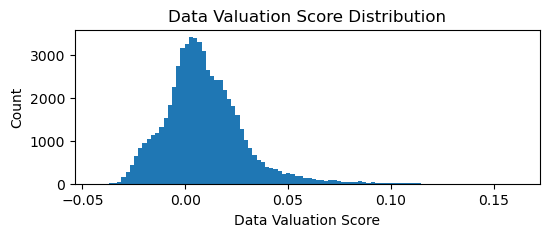

In [109]:
plt.figure(figsize=(6,2))
plt.hist(values, bins=100)
plt.xlabel('Data Valuation Score')
plt.ylabel('Count')
plt.title('Data Valuation Score Distribution')
plt.show()

# Train a model on ALL samples (baseline)

In [137]:
train_dataset = torch.utils.data.TensorDataset(x_source, y_source) 
test_dataset = torch.utils.data.TensorDataset(x_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=4)

In [138]:
model = MLP2(in_channels = len(input_names), 
          out_channels = 1, 
          hidden_channels = args.hidden_channels, 
          layers = args.n_layers, 
          nonlin = args.nonlin,
          dropout = args.dropout, 
          norm = args.norm).to(args.device)

optim = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
crit = torch.nn.MSELoss()


In [139]:
for epoch in range(args.train_epochs):
    model.train()
    losses = []

    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(args.device)
        y = y.to(args.device)

        optim.zero_grad()
        yhat = model(x)
        loss = crit(yhat, y.view(-1, 1))
        loss.backward()
        optim.step()

        losses.append(loss.item())

    print(f'Epoch {epoch} | Train Loss: {np.mean(losses):.4f}')

Epoch 0 | Train Loss: 1.0766
Epoch 1 | Train Loss: 0.7320
Epoch 2 | Train Loss: 0.5674
Epoch 3 | Train Loss: 0.5181
Epoch 4 | Train Loss: 0.4924
Epoch 5 | Train Loss: 0.4770
Epoch 6 | Train Loss: 0.4593


KeyboardInterrupt: 

In [ ]:
model.eval()

# evaluate model on test set  

yhat, y, x = predict(model, test_loader) 

r = np.corrcoef(yhat.reshape(-1), y.reshape(-1))[0,1]
r2 = r2_score(yhat.reshape(-1), y.reshape(-1))
mse = np.mean((yhat.reshape(-1) - y.reshape(-1))**2)

print(f'r: {r:.4f}, r2: {r2:.4f}, mse: {mse:.4f}')

plt.figure(figsize=(3,3))
plt.plot(yhat.reshape(-1), y.reshape(-1), 'k.', alpha=0.1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Baseline Model')
plt.show()

r: 0.7119, r2: 0.2250, mse: 0.4633


In [ ]:
target_dataset = torch.utils.data.TensorDataset(x_target, y_target) 
target_loader = torch.utils.data.DataLoader(target_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)

yhat, y, x = predict(model, target_loader) 

r = np.corrcoef(yhat.reshape(-1), y.reshape(-1))[0,1]
r2 = r2_score(yhat.reshape(-1), y.reshape(-1))
mse = np.mean((yhat.reshape(-1) - y.reshape(-1))**2)

print(f'r: {r:.4f}, r2: {r2:.4f}, mse: {mse:.4f}')

plt.figure(figsize=(3,3))
plt.plot(yhat.reshape(-1), y.reshape(-1), 'k.', alpha=0.1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Baseline Model')
plt.show()

# Train a model on only high value samples (>0)

In [141]:
train_dataset = torch.utils.data.TensorDataset(x_source[good_samples], y_source[good_samples]) 
test_dataset = torch.utils.data.TensorDataset(x_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=4)

In [142]:
model = MLP2(in_channels = len(input_names), 
          out_channels = 1, 
          hidden_channels = args.hidden_channels, 
          layers = args.n_layers, 
          nonlin = args.nonlin,
          dropout = args.dropout, 
          norm = args.norm).to(args.device)

optim = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
crit = torch.nn.MSELoss()


In [ ]:
for epoch in range(args.train_epochs):
    model.train()
    losses = []

    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(args.device)
        y = y.to(args.device)

        optim.zero_grad()
        yhat = model(x)
        loss = crit(yhat, y.view(-1, 1))
        loss.backward()
        optim.step()

        losses.append(loss.item())

    print(f'Epoch {epoch} | Train Loss: {np.mean(losses):.4f}')

Epoch 0 | Train Loss: 1.0306
Epoch 1 | Train Loss: 0.7435
Epoch 2 | Train Loss: 0.5534
Epoch 3 | Train Loss: 0.4784
Epoch 4 | Train Loss: 0.4458
Epoch 5 | Train Loss: 0.4344
Epoch 6 | Train Loss: 0.4287
Epoch 7 | Train Loss: 0.4196
Epoch 8 | Train Loss: 0.4112
Epoch 9 | Train Loss: 0.4054
Epoch 10 | Train Loss: 0.4095
Epoch 11 | Train Loss: 0.4006
Epoch 12 | Train Loss: 0.3880
Epoch 13 | Train Loss: 0.3883
Epoch 14 | Train Loss: 0.3825
Epoch 15 | Train Loss: 0.3822
Epoch 16 | Train Loss: 0.3788
Epoch 17 | Train Loss: 0.3687
Epoch 18 | Train Loss: 0.3660
Epoch 19 | Train Loss: 0.3632
Epoch 20 | Train Loss: 0.3607
Epoch 21 | Train Loss: 0.3589
Epoch 22 | Train Loss: 0.3573
Epoch 23 | Train Loss: 0.3497
Epoch 24 | Train Loss: 0.3513


In [ ]:
# evaluate model on test set  
model.eval() 

yhat, y, x = predict(model, test_loader) 

r = np.corrcoef(yhat.reshape(-1), y.reshape(-1))[0,1]
r2 = r2_score(yhat.reshape(-1), y.reshape(-1))
mse = np.mean((yhat.reshape(-1) - y.reshape(-1))**2)

print(f'r: {r:.4f}, r2: {r2:.4f}, mse: {mse:.4f}')

plt.figure(figsize=(3,3))
plt.plot(yhat.reshape(-1), y.reshape(-1), 'k.', alpha=0.1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Baseline Model')
plt.show()


r: 0.6431, r2: -0.2716, mse: 0.6104


In [ ]:
target_dataset = torch.utils.data.TensorDataset(x_target, y_target) 
target_loader = torch.utils.data.DataLoader(target_dataset, batch_size=args.batch_size, shuffle=True, num_workers=4)

yhat, y, x = predict(model, target_loader) 

r = np.corrcoef(yhat.reshape(-1), y.reshape(-1))[0,1]
r2 = r2_score(yhat.reshape(-1), y.reshape(-1))
mse = np.mean((yhat.reshape(-1) - y.reshape(-1))**2)

print(f'r: {r:.4f}, r2: {r2:.4f}, mse: {mse:.4f}')

plt.figure(figsize=(3,3))
plt.plot(yhat.reshape(-1), y.reshape(-1), 'k.', alpha=0.1)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Baseline Model')
plt.show()


r: 0.6650, r2: -0.3125, mse: 0.6073
